<a href="https://colab.research.google.com/github/benplic/quantum-computing-learning/blob/main/notebooks/quantum_phase_estimation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**The Beginning**

In order to understand phase estimation I first had to understand Spectral Theorem because the two are related in a fascinating way. While there is more to it, the most important implication of spectral theorem is this:

> Given a square matrix $U$ with dimensions $N×N$, there exists some orthonormal basis $\{\vert \psi _1\rangle…\vert\psi_N\rangle\}$ of vectors along with complex numbers $\lambda_1=e^{2πi\theta_1} \dots \lambda_N=e^{2πiθ_N}$ such that $U=∑_{k=1}^N λ_k\vert \psi_k \rangle \langle \psi_k \vert$

This is the spectral decomposition, and this shows that each vector $\vert\psi_k\rangle$ is an eigenvector of $U$ with an eigenvalue of $\lambda_k$. That is to say, $$U\vert \psi_k \rangle = e^{2πi\theta_k}$$



**The Phase Estimation Problem**

Given a description of a quantum circuit, $U$, on n qubits and an n-qubit quantum state $\vert\psi\rangle$, and knowing that $\vert\psi\rangle$ is an eigenvalue of $U$, approximate the number $θ \in [0,1)$ satisfying $U\vert\psi\rangle = e^{2πi\theta}\vert\psi\rangle$.

Since standard phases range over $θ \in [0,1)$, adding in $\theta$ allows for a binary fraction output by a program to estimate a specific phase.

$$\theta = 0.\theta_1 \theta_2 \theta_3 …= \sum_{k=1}^{\infty} \theta_k 2^{-k}, \quad \theta_k \in \{0, 1\}$$

In [1]:
!uv pip install qiskit qiskit-aer

Using Python 3.13.15 environment at: /usr
Checked 2 packages in 232ms


In [2]:
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit.circuit.library import QFT
from qiskit_aer import AerSimulator
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit.visualization import plot_histogram
import numpy as np
import matplotlib.pyplot as plt
import time

def bitstring_to_phase(bitstring: str, t:int) -> float:
  decimal = int(bitstring, 2)
  return decimal/(2**t)

In [3]:
#Set counting register size
t = 4
#Set test phase
theta = 0.37

shots = 8192
#create circuit
def build_qpe_circuit(t: int, theta: float) -> QuantumCircuit:
  counting = QuantumRegister(t,"c")
  target = QuantumRegister(1,"t")
  measure = ClassicalRegister(t,"m")
  qc = QuantumCircuit(counting,target,measure)

  #step 1: intitialize circuit
  for qubit in counting:
    qc.h(qubit)

  for qubit in target:
    qc.x(qubit)

  #step 2: phase kickback
  for j in range(t):
    #calculate scaled angle for 2^j to conserve resources
    angle = 2 * np.pi * theta * (2**j)

    #apply gate
    qc.cp(angle,counting[j],target[0])

  #step 3: recovery (inverse QFT)
  inverseQFT = QFT(t,do_swaps=True,inverse=True)

  qc.append(inverseQFT,counting)

  #step 4: measure
  qc.measure(counting,measure)

  return qc

In [4]:
qc = build_qpe_circuit(t, theta)
qc.draw('text')

/tmp/ipykernel_12853/3328756519.py:30: DeprecationWarning: The class ``qiskit.circuit.library.basis_change.qft.QFT`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. ('Use qiskit.circuit.library.QFTGate or qiskit.synthesis.qft.synth_qft_full instead, for access to all previous arguments.',)
  inverseQFT = QFT(t,do_swaps=True,inverse=True)


┌───┐                                                ┌───────┐┌─┐         
c_0: ┤ H ├─■──────────────────────────────────────────────┤0      ├┤M├─────────
     ├───┤ │                                              │       │└╥┘┌─┐      
c_1: ┤ H ├─┼───────────■──────────────────────────────────┤1      ├─╫─┤M├──────
     ├───┤ │           │                                  │  IQFT │ ║ └╥┘┌─┐   
c_2: ┤ H ├─┼───────────┼───────────■──────────────────────┤2      ├─╫──╫─┤M├───
     ├───┤ │           │           │                      │       │ ║  ║ └╥┘┌─┐
c_3: ┤ H ├─┼───────────┼───────────┼───────────■──────────┤3      ├─╫──╫──╫─┤M├
     ├───┤ │P(2.3248)  │P(4.6496)  │P(9.2991)  │P(18.598) └───────┘ ║  ║  ║ └╥┘
  t: ┤ X ├─■───────────■───────────■───────────■────────────────────╫──╫──╫──╫─
     └───┘                                                          ║  ║  ║  ║ 
m: 4/═══════════════════════════════════════════════════════════════╩══╩══╩══╩═
                                                                    0  1  2  3

In [5]:
#Simulate!
backend = AerSimulator()

#pass manager to transpile my circuit for simulator
pm = generate_preset_pass_manager(backend=backend,optimization_level=1)

def simulate_Circuit(qc: QuantumCircuit) -> dict:
  transpiled_circuit = pm.run(qc)

  #run it!
  job = backend.run(transpiled_circuit, shots=shots)
  result = job.result()

  counts = result.get_counts()
  return(counts)

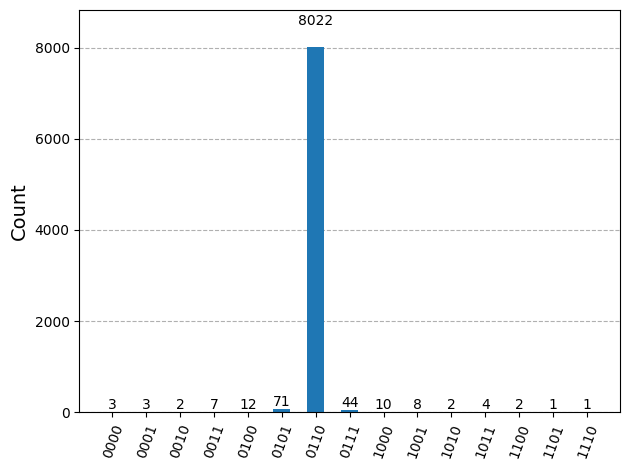

In [6]:
counts = simulate_Circuit(qc)
plot_histogram(counts)

Now that I know the function works with 4 qubits, lets examine the differences between qubit register sizes in terms of accuracy and (rough) speed.

In [31]:
tSizes = 16 #the circuit will iterate through t = [3,tSizes]
theta_real = 0.37

def QPE(tSizes: int, theta_real: float, print: bool):
  results_data = []

  for t in range(3,tSizes+1):
    qc = build_qpe_circuit(t,theta_real)

    start = time.perf_counter()
    counts = simulate_Circuit(qc)
    end = time.perf_counter()
    elapsed_time = end-start

    best_bitstring = max(counts, key=counts.get)
    best_count = counts[best_bitstring]
    prob = (best_count / shots)*100
    theta_est = bitstring_to_phase(best_bitstring,t)
    error = abs(theta_real-theta_est)

    results_data.append({
        "t": t,
        "bitstring": best_bitstring,
        "theta_est": theta_est,
        "error": error,
        "success_prob": prob,
        "raw_counts": counts,
        "time" : elapsed_time
    })

    if print: print(f"t = {t}, Phase Estimate: {theta_est:.5f}, Error: {error:.2g}, Time: {elapsed_time:.3g}s, Prob: {prob:.3g}%")

  #graph
  errors = [entry["error"] for entry in results_data]

  plt.figure(figsize=(7, 4))
  plt.semilogy(range(3,tSizes+1), errors, marker="o", linestyle="--", color="crimson")
  plt.xlabel("Number of Counting Qubits")
  plt.ylabel("Estimation Error")
  plt.title(
      f"QPE Error Scaling for Non-Dyadic Phase $\\theta = {theta_real}$ (Log"
      " Scale)"
  )
  plt.grid(True, which="both", linestyle=":", alpha=0.6)
  plt.show()

/tmp/ipykernel_12853/3328756519.py:30: DeprecationWarning: The class ``qiskit.circuit.library.basis_change.qft.QFT`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. ('Use qiskit.circuit.library.QFTGate or qiskit.synthesis.qft.synth_qft_full instead, for access to all previous arguments.',)
  inverseQFT = QFT(t,do_swaps=True,inverse=True)


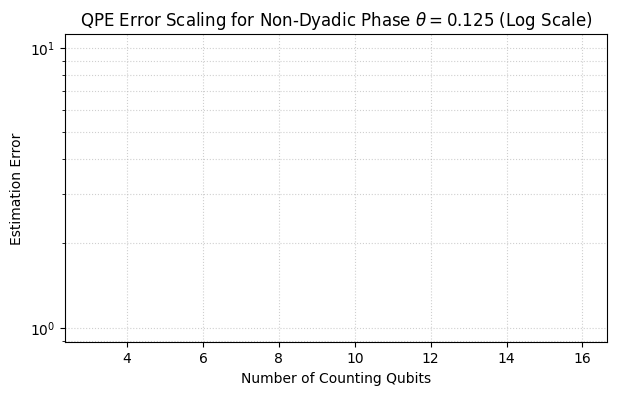

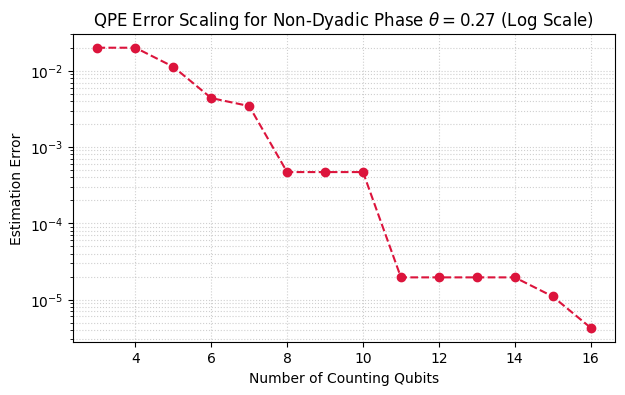

In [32]:
QPE(16,0.125,False)
QPE(16,0.27,False)